# EDA — Vila Hotell (Booking.com)

Análise exploratória das avaliações reais do hotel exportadas do Booking.com.

**Objetivo:** entender qualidade, distribuição e características dos dados antes de qualquer uso em modelagem.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid', palette='muted')

RAW_PATH = Path(r'C:\Users\João Marcelo\OneDrive\Downloads\reviews.csv')

## 1. Carregamento

In [34]:
df = pd.read_csv(RAW_PATH, quoting=0)
df.columns = [
    'review_date', 'guest_name', 'reservation_id',
    'review_title', 'positive', 'negative',
    'score', 'staff', 'cleanliness', 'location',
    'facilities', 'comfort', 'value', 'property_reply'
]
df['review_date'] = pd.to_datetime(df['review_date'])

print(f'Shape: {df.shape}')
df.head(3)

Shape: (3422, 14)


,review_date,guest_name,reservation_id,review_title,positive,negative,score,staff,cleanliness,location,facilities,comfort,value,property_reply
0,2023-05-18 00:18:38,Capaverde,3.015283e+09,NaN,Excelente café da manhã \nFuncionários atenciosos,NaN,9.0,10.0,10.0,10.0,10.0,7.5,10.0,NaN
1,2023-05-18 02:30:25,Barreto,3.631771e+09,"O hotel é bem agradável e tranquilo, por isso gostei e recomendo.",Café da manhã satisfatório. O hotel teve localização adequada para a minha necessidade durante a estadia.,O restaurante poderia ter refeições para almoço e jantar.,9.0,10.0,10.0,7.5,7.5,7.5,7.5,NaN
2,2023-05-18 15:54:58,Nick Anderson,2.985295e+09,NaN,NaN,NaN,10.0,10.0,10.0,10.0,10.0,10.0,10.0,NaN


## 2. Visão geral — tipos e nulos

In [35]:
missing = df.isnull().sum().rename('nulls')
missing_pct = (df.isnull().mean() * 100).rename('null_%').round(1)
print(pd.concat([df.dtypes.rename('dtype'), missing, missing_pct], axis=1).to_string())

                         dtype  nulls  null_%
review_date     datetime64[ns]      0     0.0
guest_name              object     13     0.4
reservation_id         float64     13     0.4
review_title            object   2228    65.1
positive                object   1529    44.7
negative                object   1825    53.3
score                  float64      0     0.0
staff                  float64     16     0.5
cleanliness            float64     17     0.5
location               float64     14     0.4
facilities             float64     15     0.4
comfort                float64     14     0.4
value                  float64     17     0.5
property_reply          object   3315    96.9


In [36]:
# Campos de texto vazios (string vazia vs NaN)
for col in ['review_title', 'positive', 'negative', 'property_reply']:
    empty = (df[col].fillna('').str.strip() == '').sum()
    print(f'{col:20s}  vazio/nulo: {empty:4d}  ({empty/len(df)*100:.1f}%)')

review_title          vazio/nulo: 2228  (65.1%)
positive              vazio/nulo: 1530  (44.7%)
negative              vazio/nulo: 1826  (53.4%)
property_reply        vazio/nulo: 3315  (96.9%)


## 3. Distribuição de notas

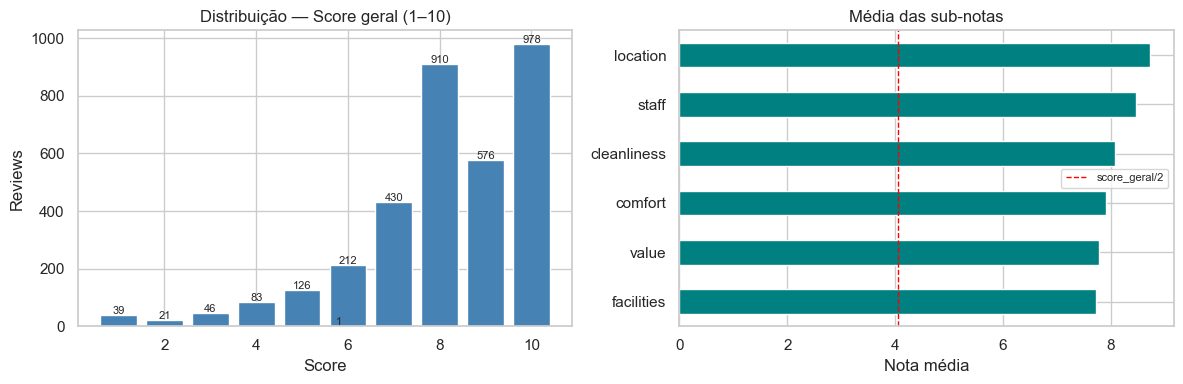

Score médio: 8.10 | Mediana: 8.0


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Score geral
score_counts = df['score'].value_counts().sort_index()
axes[0].bar(score_counts.index, score_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição — Score geral (1–10)')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Reviews')
for x, y in zip(score_counts.index, score_counts.values):
    axes[0].text(x, y + 5, str(y), ha='center', fontsize=8)

# Sub-ratings
sub_cols = ['staff', 'cleanliness', 'location', 'facilities', 'comfort', 'value']
df[sub_cols].mean().sort_values().plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title('Média das sub-notas')
axes[1].set_xlabel('Nota média')
axes[1].axvline(df['score'].mean() / 2, color='red', linestyle='--', linewidth=1, label='score_geral/2')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f'Score médio: {df["score"].mean():.2f} | Mediana: {df["score"].median()}')

## 4. Volume ao longo do tempo

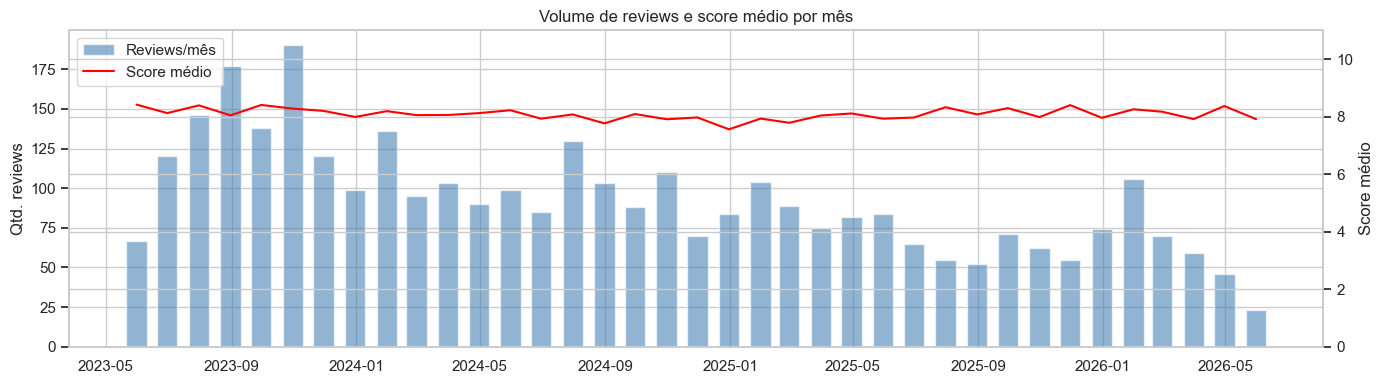

In [38]:
monthly = df.set_index('review_date').resample('ME').agg(
    count=('score', 'count'),
    avg_score=('score', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()

ax1.bar(monthly['review_date'], monthly['count'], width=20, color='steelblue', alpha=0.6, label='Reviews/mês')
ax2.plot(monthly['review_date'], monthly['avg_score'], color='red', linewidth=1.5, label='Score médio')

ax1.set_ylabel('Qtd. reviews')
ax2.set_ylabel('Score médio')
ax2.set_ylim(0, 11)
ax1.set_title('Volume de reviews e score médio por mês')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()

## 5. Análise dos textos

In [39]:
# Comprimento dos textos
df['len_positive'] = df['positive'].fillna('').str.len()
df['len_negative'] = df['negative'].fillna('').str.len()
df['has_positive'] = df['len_positive'] > 0
df['has_negative'] = df['len_negative'] > 0

print(f'Reviews com texto positivo: {df["has_positive"].sum()} ({df["has_positive"].mean()*100:.1f}%)')
print(f'Reviews com texto negativo: {df["has_negative"].sum()} ({df["has_negative"].mean()*100:.1f}%)')
print(f'Reviews com AMBOS:          {(df["has_positive"] & df["has_negative"]).sum()}')
print(f'Reviews sem nenhum texto:   {(~df["has_positive"] & ~df["has_negative"]).sum()}')

Reviews com texto positivo: 1893 (55.3%)
Reviews com texto negativo: 1597 (46.7%)
Reviews com AMBOS:          1513
Reviews sem nenhum texto:   1445


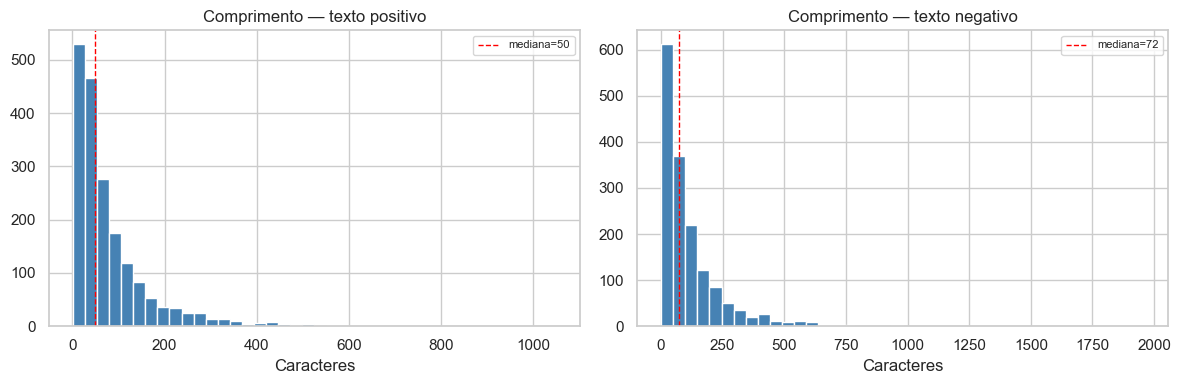

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in zip(axes,
    ['len_positive', 'len_negative'],
    ['Comprimento — texto positivo', 'Comprimento — texto negativo']):
    data = df[df[col] > 0][col]
    ax.hist(data, bins=40, color='steelblue', edgecolor='white')
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=1, label=f'mediana={data.median():.0f}')
    ax.set_title(title)
    ax.set_xlabel('Caracteres')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Correlação entre sub-notas e score geral

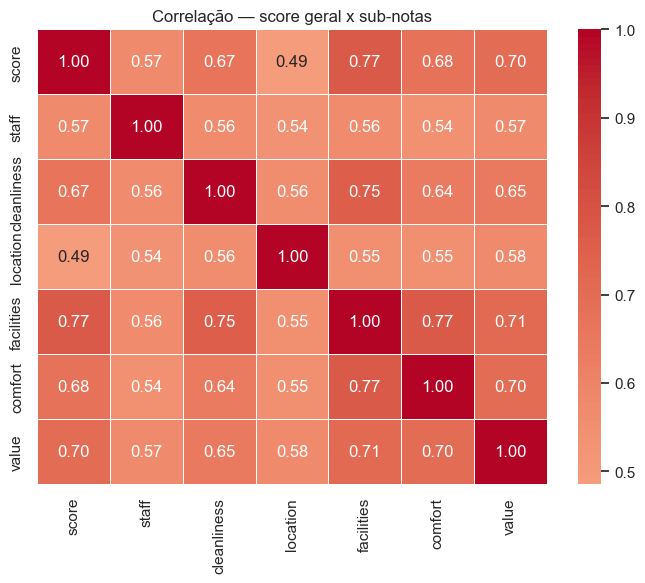

In [41]:
corr_cols = ['score', 'staff', 'cleanliness', 'location', 'facilities', 'comfort', 'value']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Correlação — score geral x sub-notas')
plt.tight_layout()
plt.show()

## 7. Property reply — taxa de resposta

In [42]:
df['has_reply'] = df['property_reply'].fillna('').str.strip() != ''
reply_rate = df['has_reply'].mean() * 100
print(f'Taxa de resposta do hotel: {reply_rate:.1f}%')

# Score médio com/sem resposta
print(df.groupby('has_reply')['score'].agg(['mean', 'count']).rename(
    columns={'mean': 'score_médio', 'count': 'qtd'}))

Taxa de resposta do hotel: 3.1%
           score_médio   qtd
has_reply                   
False         8.104917  3315
True          7.897196   107


## 8. Limpeza e criacao dos subsets

In [43]:
# Flags de cobertura de texto
has_pos = df['positive'].fillna('').str.strip() != ''
has_neg = df['negative'].fillna('').str.strip() != ''

# df_full: todas as reviews (análises de negócio, score, sazonalidade)
df_full = df.copy()

# df_model: apenas reviews com pelo menos um campo de texto
df_model = df[has_pos | has_neg].copy().reset_index(drop=True)

print(f'df_full  → {len(df_full):4d} reviews (100%)')
print(f'df_model → {len(df_model):4d} reviews ({len(df_model)/len(df_full)*100:.1f}%) — com texto')
print(f'Descartadas (sem texto): {len(df_full) - len(df_model)}')

df_full  → 3422 reviews (100%)
df_model → 1977 reviews (57.8%) — com texto
Descartadas (sem texto): 1445


In [44]:
# Construção do review_text: positivo + negativo separados por " | "
def build_review_text(row):
    parts = []
    pos = str(row['positive']).strip() if pd.notna(row['positive']) else ''
    neg = str(row['negative']).strip() if pd.notna(row['negative']) else ''
    if pos:
        parts.append(pos)
    if neg:
        parts.append(neg)
    return ' | '.join(parts)

df_model['review_text'] = df_model.apply(build_review_text, axis=1)

# Comprimento do texto combinado
df_model['review_len'] = df_model['review_text'].str.len()

print('Comprimento do review_text (caracteres):')
print(df_model['review_len'].describe().round(1))
print()
print('Amostra:')
df_model[['positive', 'negative', 'review_text']].head(3)

Comprimento do review_text (caracteres):
count    1977.0
mean      175.1
std       182.8
min         3.0
25%        60.0
50%       120.0
75%       224.0
max      2048.0
Name: review_len, dtype: float64

Amostra:


,positive,negative,review_text
0,Excelente café da manhã \nFuncionários atenciosos,NaN,Excelente café da manhã \nFuncionários atenciosos
1,Café da manhã satisfatório. O hotel teve localização adequada para a minha necessidade durante a estadia.,O restaurante poderia ter refeições para almoço e jantar.,Café da manhã satisfatório. O hotel teve localização adequada para a minha necessidade durante a estadia. | O restau...
2,hotel bem conservado,achei quarto muito pequeno,hotel bem conservado | achei quarto muito pequeno


Distribuição do score normalizado (df_model):
score_5
0.5     32
1.0     13
1.5     38
2.0     74
2.5     92
2.9      1
3.0    144
3.5    258
4.0    509
4.5    306
5.0    510
Name: count, dtype: int64


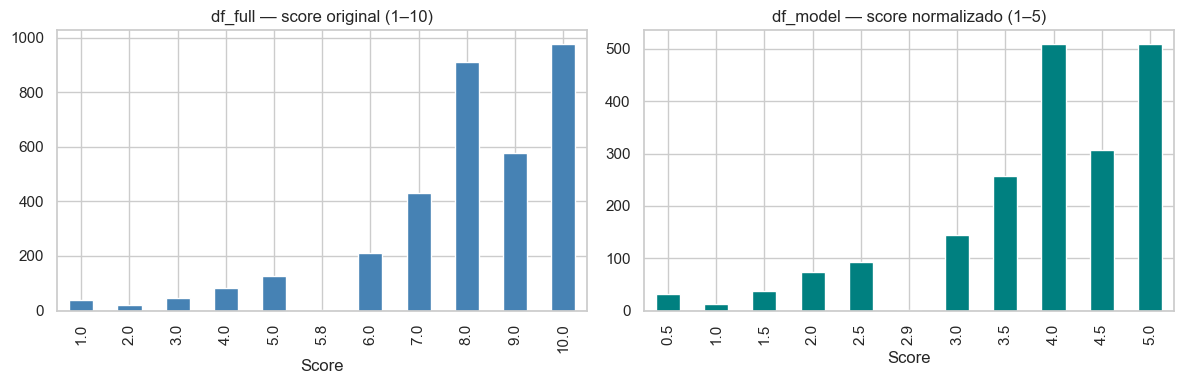

In [45]:
# Normalização do score: Booking usa 1–10, modelo usa 1–5
# score_norm = (score / 10) para treino (MSELoss com target em [0,1])
# score_5 = score / 2 para comparação com Kaggle
df_model['score_norm'] = df_model['score'] / 10
df_model['score_5'] = df_model['score'] / 2

print('Distribuição do score normalizado (df_model):')
print(df_model['score_5'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_full['score'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('df_full — score original (1–10)')
axes[0].set_xlabel('Score')

df_model['score_5'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('df_model — score normalizado (1–5)')
axes[1].set_xlabel('Score')

plt.tight_layout()
plt.show()

In [46]:
# Colunas finais do df_model para o pipeline de modelagem
cols_final = [
    'review_date', 'guest_name', 'reservation_id',
    'review_text', 'score', 'score_norm', 'score_5',
    'staff', 'cleanliness', 'location', 'facilities', 'comfort', 'value'
]
df_model_clean = df_model[cols_final].copy()

print(f'df_model_clean: {df_model_clean.shape}')
print(f'Nulos restantes:')
print(df_model_clean.isnull().sum()[df_model_clean.isnull().sum() > 0])
df_model_clean.head(3)

df_model_clean: (1977, 13)
Nulos restantes:
guest_name        6
reservation_id    6
staff             2
cleanliness       4
location          4
facilities        3
comfort           1
value             2
dtype: int64


,review_date,guest_name,reservation_id,review_text,score,score_norm,score_5,staff,cleanliness,location,facilities,comfort,value
0,2023-05-18 00:18:38,Capaverde,3.015283e+09,Excelente café da manhã \nFuncionários atenciosos,9.0,0.9,4.5,10.0,10.0,10.0,10.0,7.5,10.0
1,2023-05-18 02:30:25,Barreto,3.631771e+09,Café da manhã satisfatório. O hotel teve localização adequada para a minha necessidade durante a estadia. | O restau...,9.0,0.9,4.5,10.0,10.0,7.5,7.5,7.5,7.5
2,2023-05-19 02:05:56,Orlando,3.922637e+09,hotel bem conservado | achei quarto muito pequeno,8.0,0.8,4.0,10.0,7.5,10.0,10.0,10.0,7.5


## 9. Sumario - Achados da EDA

### Dados brutos (df_full - 3.422 reviews)
- **Score medio:** 8.10/10 | concentrado em notas altas (8, 9, 10 somam 69% das reviews)
- **Taxa de resposta do hotel:** 3.1% (107 reviews respondidas, score medio 7.9 - respondem quando ha reclamacao)
- **Anomalia:** 1 review com score 5.8 (unico valor nao-inteiro) - tratar como 6 (neutro)

### Distribuicao de sentimento (escala original 1-10)
| Classe | Scores | Reviews (df_full) | % |
|--------|--------|-------------------|---|
| Negativo | 1-4 | 189 | 5.5% |
| Neutro | 5-6 | 339 | 9.9% |
| Positivo | 7-10 | 2.894 | 84.6% |

Desbalanceamento mais severo que o Kaggle (84.6% vs 71% positivo, 5.5% vs 9% negativo).

### Cobertura de texto (df_model - 1.977 reviews)
- Texto positivo: 55.3% | Texto negativo: 46.6%
- Com pelo menos um dos dois: **57.8% (1.977)** - base do modelo
- Sem nenhum texto: 42.2% (1.445) - so nota, descartadas

### Comprimento do review_text
- Mediana: 120 chars | Media: 175 chars | P25: 60 | P75: 224 | Max: 2.048
- Reviews com < 15 chars: filtrar (ruido)

### Decisoes fixadas para modelagem
-  =  +  + 
- Score normalizado:  para MSELoss (target em [0, 1])
- Threshold de sentimento: <= 4/10 negativo . 5-6/10 neutro . >= 7/10 positivo
- Anomalia 5.8: arredondar para 6 (neutro)
- **Estrategia:** fine-tune do modelo Kaggle nos dados do Booking (nao retreinar do zero)
  - Kaggle resolve o desbalanceamento severo com 80k reviews diversificados
  - Booking adapta ao idioma (PT-BR) e ao dominio especifico do hotel
- Sub-notas (, , etc.) utilizaveis como features auxiliares (~0.5% nulos)
